# 🌳 Random Forest, Bagging, and Boosting

## 1. Random Forest
- **Definition:** An ensemble learning method that builds many decision trees and combines their results.
- **How it works:**
  1. Randomly sample data (bootstrap sampling).
  2. Build decision trees on each sample.
  3. At each split, only a random subset of features is considered.
  4. Final prediction:
     - Classification → Majority vote
     - Regression → Average of predictions

### ✅ Why We Use Random Forest
- Reduces overfitting
- High accuracy and stability
- Works for both classification and regression
- Handles missing data
- Suitable for large datasets

### 🌟 Advantages
- Robust and accurate
- Identifies important features
- Out-of-Bag (OOB) error gives built-in validation
- Parallel training possible
- Generalizes well across domains

### ⚠️ Limitations
- Slower predictions (many trees)
- Harder to interpret than a single tree
- Needs more memory

### 🔎 Types of Random Forest
- **Classification Random Forest** → Predict categories (e.g., spam vs not spam)
- **Regression Random Forest** → Predict numbers (e.g., house prices)
- **Feature Selection Random Forest** → Identify important variables
- **Balanced Random Forest** → Handle imbalanced datasets (e.g., fraud detection)

---

## 2. Bagging (Bootstrap Aggregating)
- **Definition:** Train multiple models on random subsets of data, then combine their results.
- **Goal:** Reduce **variance** (overfitting).
- **Example:** Random Forest is a bagging method with decision trees.
- **Key Point:** Models are trained **independently and in parallel**.

👉 Bagging = “Ask many friends independently, then take the majority answer.”

---

## 3. Boosting
- **Definition:** Train models one after another, each new model fixes the mistakes of the previous one.
- **Goal:** Reduce **bias** (make weak models stronger).
- **Examples:** AdaBoost, Gradient Boosting, XGBoost, LightGBM.
- **Key Point:** Models are trained **sequentially** and depend on each other.

👉 Boosting = “Teacher corrects student step by step, focusing on mistakes.”

---

## 4. Bagging vs Boosting (Comparison)

| Feature   | Bagging                          | Boosting                          |
|-----------|----------------------------------|-----------------------------------|
| Training  | Parallel (independent models)    | Sequential (each fixes previous)  |
| Focus     | Reduce variance                  | Reduce bias                       |
| Example   | Random Forest                    | AdaBoost, XGBoost                 |
| Speed     | Faster                           | Slower                            |
| Risk      | Less overfitting                 | Can overfit if too many rounds    |

---

## 📝 Final Simple Summary
- **Random Forest** = Many decision trees combined → accurate, stable, reduces overfitting.
- **Bagging** = Train models independently on random samples → reduces variance.
- **Boosting** = Train models sequentially, each fixing errors → reduces bias, very powerful.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
df = pd.read_csv("C:\\Users\\HP\\OneDrive\\Documents\\DataMites\\Machine learning\\indian_liver_patient.csv")

In [4]:
df.head()                 

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [4]:
df.tail()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,2
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1
582,38,Male,1.0,0.3,216,21,24,7.3,4.4,1.50,2


In [5]:
df.info

<bound method DataFrame.info of      Age  Gender  Total_Bilirubin  Direct_Bilirubin  Alkaline_Phosphotase  \
0     65  Female              0.7               0.1                   187   
1     62    Male             10.9               5.5                   699   
2     62    Male              7.3               4.1                   490   
3     58    Male              1.0               0.4                   182   
4     72    Male              3.9               2.0                   195   
..   ...     ...              ...               ...                   ...   
578   60    Male              0.5               0.1                   500   
579   40    Male              0.6               0.1                    98   
580   52    Male              0.8               0.2                   245   
581   31    Male              1.3               0.5                   184   
582   38    Male              1.0               0.3                   216   

     Alamine_Aminotransferase  Aspartate_Am

In [6]:
df.describe()

,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064,1.286449
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


In [7]:
df.isnull()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
578,False,False,False,False,False,False,False,False,False,False,False
579,False,False,False,False,False,False,False,False,False,False,False
580,False,False,False,False,False,False,False,False,False,False,False
581,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isna()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
578,False,False,False,False,False,False,False,False,False,False,False
579,False,False,False,False,False,False,False,False,False,False,False
580,False,False,False,False,False,False,False,False,False,False,False
581,False,False,False,False,False,False,False,False,False,False,False


In [9]:
df.columns

Index(['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin',
       'Albumin_and_Globulin_Ratio', 'Dataset'],
      dtype='object')

In [10]:
df.isna().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Dataset                       0
dtype: int64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [5]:
## how to convert categorical data into numerical data
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [6]:
df["Gender"] = le.fit_transform(df["Gender"])


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    int64  
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(6)
memory usage: 50.2 KB


In [7]:
df["Albumin_and_Globulin_Ratio"].fillna(df["Albumin_and_Globulin_Ratio"].median(),inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_4500\2615243068.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Albumin_and_Globulin_Ratio"].fillna(df["Albumin_and_Globulin_Ratio"].median(),inplace=True)


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    int64  
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  583 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(6)
memory usage: 50.2 KB


In [8]:
df.isna().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    0
Dataset                       0
dtype: int64

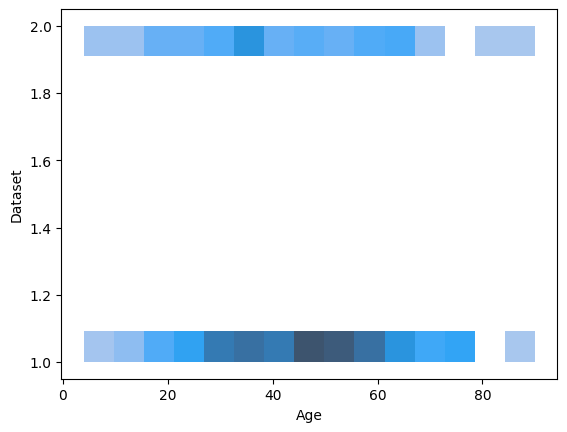

In [37]:
sns.histplot(x = 'Age',y = 'Dataset',data = df)
plt.show()

<Axes: >

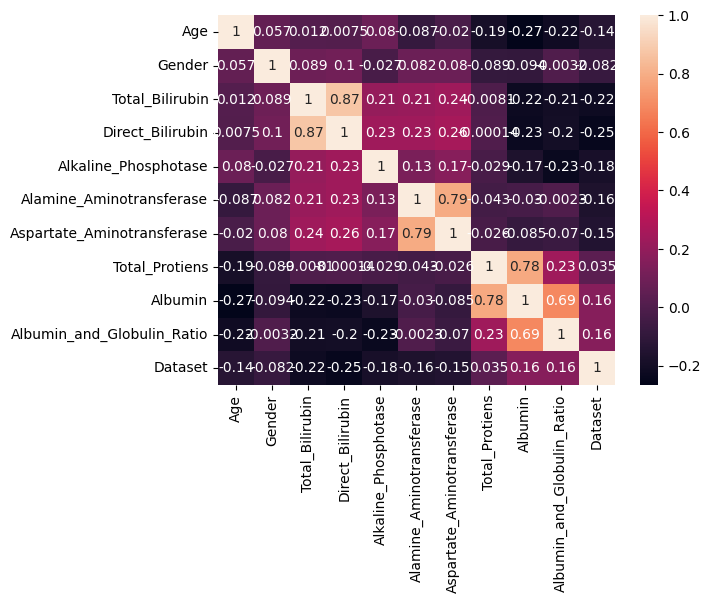

In [31]:
sns.heatmap(
      df.corr(),
      annot=True
)

In [23]:
df.columns

Index(['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin',
       'Albumin_and_Globulin_Ratio', 'Dataset'],
      dtype='object')

In [9]:
X = df[['Age', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin',
       'Albumin_and_Globulin_Ratio','Dataset']]

In [10]:
y = df["Gender"]

In [11]:
## Split X and Y 
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [12]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()

In [13]:
model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
model.score(X_test,y_test)

0.8034188034188035

In [15]:
model.predict(X_test)

array([1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1])

In [16]:
y_predict = model.predict(X_test)

In [19]:
from sklearn.metrics import confusion_matrix,classification_report
print("Classification Report")
cr = classification_report(y_test,y_predict)
print(cr)

print("Confusion Matrix")
cm = confusion_matrix(y_test,y_predict)
print(cm)


Classification Report
              precision    recall  f1-score   support

           0       0.56      0.21      0.30        24
           1       0.82      0.96      0.89        93

    accuracy                           0.80       117
   macro avg       0.69      0.58      0.59       117
weighted avg       0.77      0.80      0.77       117

Confusion Matrix
[[ 5 19]
 [ 4 89]]


<Axes: >

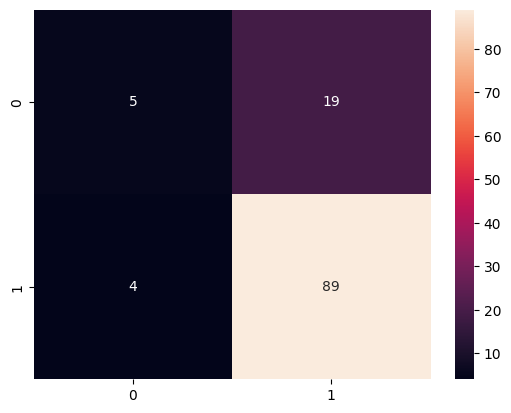

In [18]:
sns.heatmap(cm,annot=True,fmt='d')

### Bagging

In [21]:
from sklearn.ensemble import BaggingClassifier

In [23]:
model1 = BaggingClassifier()
model1.fit(X_train,y_train)
print(f"Bagging Classifier Accuracy: {model1.score(X_test, y_test)}")

Bagging Classifier Accuracy: 0.7350427350427351


In [24]:
y_predict_bagging = model1.predict(X_test)

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_predict_bagging))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_predict_bagging)
print(cm)

Classification Report:
              precision    recall  f1-score   support

           0       0.37      0.42      0.39        24
           1       0.84      0.82      0.83        93

    accuracy                           0.74       117
   macro avg       0.61      0.62      0.61       117
weighted avg       0.75      0.74      0.74       117


Confusion Matrix:
[[10 14]
 [17 76]]


In [26]:
## Gradient Boosting 

from sklearn.ensemble import GradientBoostingClassifier
model2 = GradientBoostingClassifier()

In [27]:
model2.fit(X_train,y_train)
print(f"Gradient Boosting Accuracy: {model2.score(X_test, y_test)}")

Gradient Boosting Accuracy: 0.7606837606837606


In [28]:
y_predict_gb = model2.predict(X_test)

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_predict_gb))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_predict_gb)
print(cm)

Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.25      0.30        24
           1       0.82      0.89      0.86        93

    accuracy                           0.76       117
   macro avg       0.60      0.57      0.58       117
weighted avg       0.73      0.76      0.74       117


Confusion Matrix:
[[ 6 18]
 [10 83]]


In [ ]:
"""
import libraries
load dateset
EDA Head , tail , Graphs
 LabelEncoder when if object dtype
Feature selection = X , Y divide
Train_test_split
model.fit
model.score
model.predict
classification_report
Confusion matrix
"""

"""
## Gradient Boosting =
Feature selection = X , Y divide
Train_test_split
model.fit
model.score
model.predict
classification_report
Confusion matrix
 """

"""
### Bagging = 
Feature selection = X , Y divide
Train_test_split
model.fit
model.score
model.predict
classification_report
Confusion matrix
"""